In [2]:
import pandas as pd

# import data
df = pd.read_csv('./ai_anthropomorphism_survey.csv')

# remove ID, Start time, Completion time, email (every entry given is "anonymous"), Name and Last modified time (both blank), Code for information withdrawal, not necessary for data analysis
df = df.drop(columns=df.columns[[0,1,2,3,4,5]])

In [3]:
pd.set_option('display.max_columns', None)
#print(df.columns.tolist()) - used when coding to determine column names so they can by combined/renamed

In [4]:
# renaming columns

# where multiple questions are used to measure one thing, they are formatted as 'section_n_subset'
# lit - questions related to llm literacy
# idaq - individual differnces in anthropomorphism questionnaire, measures tendency to anthropomorphise, split into n - nature and t - technology.
# st - social tendency
# r - reciprocity
# s - substitution
# ex - experience
# ag - agency

df = df.rename(columns = {'I consent to take part in this research having read the above information and confirm that I am a UK resident and over 18 years old.\n':'consent', 
                          'How old are you?':'age', 'What is your gender?':'gender', 'What is the highest level of education you have completed?':'education_level', 
                          'What best describes your primary academic or professional background?':'background', 
                          'How often do you use a general-purpose LLMs such as ChatGPT, Claude or Gemini?':'use_frequency', 
                          'How long have you been using LLMs regularly?':'time_since_adoption', 'How long do you typically spend in a single session with an LLM?':'session_duration', 
                          'Which of the following general-purpose LLMs you have used in the past 3 months? Select all that apply.':'LLM', 
                         'Which of the following best describes how you most commonly use LLMs? Select all that apply.':'use_case',
                         'How often do you use LLMs for personal or emotionally significant conversations, as opposed to practical tasks?':'emotional_frequency', 
                         'When interacting with an LLM, how often do you use polite language such as "please" or "thank you"?':'polite_frequency',
                         'What best describes your reason for using polite language? Select all that apply.':'polite_reason',
                         'How does an LLM like ChatGPT primarily generate its responses?':'lit_1_mc', 
                         'True or false: ChatGPT remembers the content of previous conversations by default and uses this to inform future responses.':'lit_2_tf', 
                         'True or false: an LLM will always give the same response to the same question.\n':'lit_3_tf', 
                         'True or false: LLMs understand the meaning of language in the same way humans do.':'lit_4_tf', 
                         'To what extent does a cheetah experience emotions?\n':'idaq_1_n', 
                         'To what extent does the average robot have consciousness?\n':'idaq_2_t', 
                         'To what extent does the average insect have a mind of its own?\n':'idaq_3_n', 
                         'To what extent does a television set experience emotions?\n':'idaq_4_t', 
                         'To what extent does the average reptile have consciousness?\n':'idaq_5_n',
                         'To what extent does the average computer have a mind of its own?\n':'idaq_6_t', 
                         'I sometimes look forward to conversations with LLMs.':'st_1_anticipates', 
                         'I have felt that an LLM understood me in a meaningful way.':'st_2_understands', 
                         'When an LLM expresses interest in what I am saying, it feels genuine rather than mechanical.':'r_1_interest', 
                         'I sometimes feel that an LLM is engaged with me as an individual rather than simply processing my input.':'r_2_engagement', 
                         'I have used an LLM for conversation or support when I would otherwise have talked to another person.':'s_1_direct', 
                         'I find it easier to discuss certain topics with an LLM than with people I know.':'s_2_ease', 
                         'LLMs are capable of having something like subjective experience.':'ex_1_capable', 
                          'When an LLM produces a response, something is happening internally that resembles a mental state. ':'ex_2_internal', 
                         'LLMs can have states that function like emotions, even if these differ from human emotions':'ex_3_emotion', 
                         'It is possible that current LLMs have some form of inner life.':'ex_4_life', 
                         'LLMs genuinely understand the meaning of what they say, rather than processing statistical patterns':'ag_1_meaning', 
                         'When an LLM expresses curiosity or enthusiasm, this reflects something real about its internal state.':'ag_2_drive', 
                         'LLMs have something that functions like preferences, even if these are not consciously chosen.':'ag_3_prefers', 
                         'An LLM can have intentions about the outcome of a conversation.':'ag_4_intention'})

In [5]:
# optional code to remove responses which did not give consent - optional since all responses gave consent.
# df = df[df['consent'].isin(['I Agree'])]

In [6]:
# in order to undergo the regression ordinal variables are mapped to numbers


# adjusting age variable - using the midpoint (treating 65+ as equally sized to the previous bin)
# specifies the mappings
age_map = {
    '18-24': 21,
    '25-29': 27,
    '30-34': 32,
    '35-44': 39.5,
    '45-54': 49.5,
    '55-64': 59.5,
    '65+': 69.5}

# saves age bins for graphing
df['age_group'] = df['age']
# applies the mapping
df['age'] = df['age'].map(age_map)

education_map = {
    'Left school without qualifications': 0,
    'GCSE/Standard grade': 1,
    'A-level/Higher grade': 2,
    'Certificate/Diploma/NVQ': 2,
    'Degree': 3,
    'Postgraduate': 4,
    'Doctoral': 5,
    'Other': 3}

df['education_level'] = df['education_level'].map(education_map)

frequency_map = {
    'More than once a day': 6,
    'Daily': 5,
    'Multiple times a week': 4,
    'Weekly': 3,
    'Monthly': 2,
    'Less than once a month': 1,
    'Never': 0 }

df['use_frequency'] = df['use_frequency'].map(frequency_map)

time_since_adoption_map = {
    'Less than 3 months': 1,
    '3-6 months': 2,
    '6-12 months': 3,
    '1-2 years': 4,
    'More than 2 years': 5}

df['time_since_adoption'] = df['time_since_adoption'].map(time_since_adoption_map)

# 1+ hours mapped to same number due to limited responses in these bins
session_duration_map = {
    'Under 5 minutes': 1,
    '5-15 minutes': 2,
    '15-30 minutes': 3,
    '30-60 minutes': 4,
    '1-2 hours': 5,
    '2-3 hours': 5,
    '4+ hours': 5}

df['session_duration'] = df['session_duration'].map(session_duration_map)

emotional_frequency_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Very often': 4}

df['emotional_frequency'] = df['emotional_frequency'].map(emotional_frequency_map)

polite_frequency_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Always': 4}

df['polite_frequency'] = df['polite_frequency'].map(polite_frequency_map)

In [7]:
# create variable for literacy
# if correct True becomes 1, in incorrect False becomes 0 so they can simply be summed to create the score
df['literacy'] = ((df['lit_1_mc'] == 'By predicting the most likely word or token based on patterns in training data').astype(int) + (df['lit_2_tf'] == 'FALSE').astype(int)
                  + (df['lit_3_tf'] == 'FALSE').astype(int) + (df['lit_4_tf'] == 'FALSE').astype(int))

# drops no longer needed columns
df = df.drop(columns=['lit_1_mc', 'lit_2_tf', 'lit_3_tf', 'lit_4_tf'])

In [8]:
# create variable(s) for IDAQ
df['idaq'] = df[['idaq_1_n', 'idaq_2_t', 'idaq_3_n', 'idaq_4_t', 'idaq_5_n', 'idaq_6_t']].mean(axis=1)

# df['idaq_n'] = df[['idaq_1_n', 'idaq_3_n', 'idaq_5_n']].mean(axis=1)
# df['idaq_t'] = df[['idaq_2_t', 'idaq_4_t', 'idaq_6_t']].mean(axis=1)

df = df.drop(columns=['idaq_1_n', 'idaq_2_t', 'idaq_3_n', 'idaq_4_t', 'idaq_5_n', 'idaq_6_t'])

In [9]:
# likert conversions

likert_map_5 = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Neither agree nor disagree': 3,
    'Agree': 4,
    'Strongly agree': 5}

likert_map_7 = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Somewhat disagree': 3,
    'Neither agree nor disagree': 4,
    'Somewhat agree': 5,
    'Agree': 6,
    'Strongly agree': 7}

# could make this code better
df['st_1_anticipates'] = df['st_1_anticipates'].map(likert_map_5)
df['st_2_understands'] = df['st_2_understands'].map(likert_map_5)
df['r_1_interest'] = df['r_1_interest'].map(likert_map_5)
df['r_2_engagement'] = df['r_2_engagement'].map(likert_map_5)
df['s_1_direct'] = df['s_1_direct'].map(likert_map_5)
df['s_2_ease'] = df['s_2_ease'].map(likert_map_5)

df['ex_1_capable'] = df['ex_1_capable'].map(likert_map_7)
df['ex_2_internal'] = df['ex_2_internal'].map(likert_map_7)
df['ex_3_emotion'] = df['ex_3_emotion'].map(likert_map_7)
df['ex_4_life'] = df['ex_4_life'].map(likert_map_7)
df['ag_1_meaning'] = df['ag_1_meaning'].map(likert_map_7)
df['ag_2_drive'] = df['ag_2_drive'].map(likert_map_7)
df['ag_3_prefers'] = df['ag_3_prefers'].map(likert_map_7)
df['ag_4_intention'] = df['ag_4_intention'].map(likert_map_7)

In [10]:
# create variable for social tendency

df['social_tendency'] = df['st_1_anticipates'] + df['st_2_understands']

# create variable for perceived reciprocity

df['perceived_reciprocity'] = df['r_1_interest'] + df['r_2_engagement']

# create variable for relationship substitution

df['relationship_substitution'] = df['s_1_direct'] + df['s_2_ease']

# remove reference columns

df = df.drop(columns=['st_1_anticipates', 'st_2_understands', 'r_1_interest', 'r_2_engagement', 's_1_direct', 's_2_ease'])

In [11]:
# create a variable for experience and agency

df['experience'] = df['ex_1_capable'] + df['ex_2_internal'] + df['ex_3_emotion'] + df['ex_4_life']

df['agency'] = df['ag_1_meaning'] + df['ag_2_drive'] + df['ag_3_prefers'] + df['ag_4_intention']

df = df.drop(columns=['ex_1_capable', 'ex_2_internal', 'ex_3_emotion', 'ex_4_life', 'ag_1_meaning', 'ag_2_drive', 'ag_3_prefers', 'ag_4_intention'])

# create variable for mental state attribution by combining experience and agency

df['msa'] = (df['experience'] + df['agency'])

In [12]:
# creates dummy variables for each of the background responses
dummies = df['background'].str.get_dummies(sep=', ')
# formats the new dummies
dummies.columns = ['bg_' + col.lower().replace(' ', '_') for col in dummies.columns]
df = pd.concat([df, dummies], axis=1)
# removes reference column
df = df.drop(columns=['background'])

In [13]:
# combining 'other' responses by adding 1 count to the category they combine into

df['bg_stem'] = (df['bg_stem'] | df['bg_medicine_'] | df['bg_life_sciences']).astype(int) 
df = df.drop(columns=['bg_medicine_', 'bg_life_sciences'])

df['bg_business'] = (df['bg_business'] | df['bg_government_'] | df['bg_healthcare_'] | df['bg_health_care'] | df['bg_healthcare']).astype(int)
df = df.drop(columns=['bg_government_', 'bg_healthcare_', 'bg_healthcare', 'bg_health_care'])

df['bg_liberal_arts'] = (df['bg_the_liberal_arts'] | df['bg_interdisciplinary'] | df['bg_arts_and_sciences'] | df['bg_mixed']).astype(int)  
df = df.drop(columns=['bg_the_liberal_arts', 'bg_interdisciplinary', 'bg_arts_and_sciences', 'bg_mixed'])

df['bg_humanities'] = (df['bg_geography_and_environment_science_']).astype(int)
df = df.drop(columns=['bg_geography_and_environment_science_'])

In [14]:
# creating dummy variables for each of the responses for LLM model use as above

dummies = df['LLM'].str.get_dummies(sep=';')
dummies.columns = [f'llm_{col.strip().lower()}' for col in dummies.columns]
df = pd.concat([df, dummies], axis=1)
df = df.drop(columns=['LLM'])
# print(dummies.sum()) used in the process to see the names to be collapsed


In [15]:
# combining 'other' responses

df['llm_gemini'] = (df['llm_gemini'] | df['llm_the nameless google ai (seriously, ask it what it s called)']).astype(int)
    
df = df.drop(columns=['llm_the nameless google ai (seriously, ask it what it s called)', 'llm_ecosia', 'llm_perplexity', 'llm_deepseek'])

In [16]:
# creating dummy variables for use_case responses

dummies = df['use_case'].str.get_dummies(sep=';')
dummies.columns = [f'use_{col.strip().lower()}' for col in dummies.columns]
df = pd.concat([df, dummies], axis=1)
df = df.drop(columns=['use_case'])
# print(dummies.sum())

In [17]:
# combining 'other' responses

df['use_writing_assistance'] = (df['use_reword function'] | df['use_writing assistance'] | df['use_drafting documents']).astype(int) 
df = df.drop(columns=['use_reword function', 'use_drafting documents', 'use_writing assistance'])

df['use_professional_tasks'] = (df['use_administrative functions'] | df['use_business support/strategy/process refinement  and microsoft 365 business architecture'] | df['use_consolidation and refinement of work projects'] | df['use_cross checking documents & invoices'] | df['use_sop (standard operational processes)'] | df['use_transcription of recorded interviews'] | df['use_business ie/ meeting minutes/transcripts']).astype(int)
df = df.drop(columns=['use_administrative functions', 'use_business support/strategy/process refinement  and microsoft 365 business architecture', 'use_consolidation and refinement of work projects', 'use_cross checking documents & invoices', 'use_sop (standard operational processes)', 'use_transcription of recorded interviews', 'use_business ie/ meeting minutes/transcripts'])

df['use_information_search'] = (df['use_information search'] | df['use_analysis and market research'] | df['use_stock market trade analysis']).astype(int)
df = df.drop(columns=['use_analysis and market research', 'use_information search', 'use_stock market trade analysis'])

df['use_idea_generation'] = (df['use_plan generarion'] | df['use_idea generation']).astype(int)
df = df.drop(columns=['use_idea generation', 'use_plan generarion', 'use_to find the meaning of life the universe and everything.'])

df = df.rename(columns = {'use_creative projects':'use_creative_projects', 'use_general conversation':'use_general_conversation', 'use_learning or study':'use_learning_or_study', 'use_personal or emotional discussion':'use_personal_or_emotional_discussion'})

In [18]:
# creating dummy variables for polite_reason responses

dummies = df['polite_reason'].str.get_dummies(sep=';')
dummies.columns = [f'pr_{col.strip().lower()}' for col in dummies.columns]
df = pd.concat([df, dummies], axis=1)
df = df.drop(columns=['polite_reason'])
# print(dummies.sum())

df = df.rename(columns = {'pr_i am uncertain/believe that it matters to the llm':'pr_reciprocity', 
                          'pr_i think it may affect the quality of responses':'pr_response_quality', 
                          'pr_it feels uncomfortable not to':'pr_discomfort', 
                          'pr_it is a habit from human conversation':'pr_habit'})

In [19]:
df

,consent,age,gender,education_level,use_frequency,time_since_adoption,session_duration,emotional_frequency,polite_frequency,age_group,literacy,idaq,social_tendency,perceived_reciprocity,relationship_substitution,experience,agency,msa,bg_arts,bg_business,bg_humanities,bg_stem,bg_social_sciences,bg_liberal_arts,llm_chatgpt,llm_claude,llm_copilot,llm_gemini,llm_grok,use_coding,use_creative_projects,use_general_conversation,use_learning_or_study,use_personal_or_emotional_discussion,use_writing_assistance,use_professional_tasks,use_information_search,use_idea_generation,pr_reciprocity,pr_response_quality,pr_discomfort,pr_habit
0,I Agree,21.0,Female,2.0,5,3.0,4.0,4.0,0.0,18-24,2,5.500000,4,2,7,8,4,12,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0
1,I Agree,21.0,Male,2.0,2,4.0,3.0,0.0,4.0,18-24,2,5.333333,4,2,2,14,16,30,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1
2,I Agree,21.0,Female,2.0,0,NaN,NaN,NaN,NaN,18-24,2,6.000000,2,2,2,12,9,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,I Agree,39.5,Male,3.0,2,5.0,3.0,0.0,3.0,35-44,4,4.000000,3,2,5,6,5,11,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
4,I Agree,21.0,Male,2.0,6,4.0,5.0,1.0,1.0,18-24,4,3.333333,7,2,7,8,8,16,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,I Agree,59.5,Male,2.0,3,4.0,1.0,0.0,0.0,55-64,3,4.166667,2,2,2,4,10,14,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
118,I Agree,27.0,Female,2.0,1,NaN,2.0,0.0,0.0,25-29,3,4.000000,2,2,2,4,5,9,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0
119,I Agree,59.5,Female,4.0,3,3.0,3.0,1.0,3.0,55-64,2,4.500000,6,4,4,6,10,16,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1
120,I Agree,49.5,Male,3.0,6,2.0,2.0,1.0,2.0,45-54,4,3.500000,3,4,2,6,5,11,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1


In [20]:
# calculating descriptive statistics 

continuous = ['age', 'education_level', 'use_frequency', 'time_since_adoption', 'session_duration', 'emotional_frequency', 'polite_frequency', 
              'literacy', 'idaq', 'social_tendency', 'perceived_reciprocity', 'relationship_substitution', 'experience', 'agency', 'msa']

# calculates aggragated statistics for all of the continuous variables
cont_stats = df[continuous].agg(['mean', 'std', 'min', 'max']).T
cont_stats['range'] = cont_stats['max'] - cont_stats['min']
cont_stats = cont_stats.round(3)
print(cont_stats)

                             mean     std     min   max   range
age                        44.057  16.674  21.000  69.5  48.500
education_level             2.975   1.004   1.000   5.0   4.000
use_frequency               3.820   1.941   0.000   6.0   6.000
time_since_adoption         3.190   1.134   1.000   5.0   4.000
session_duration            2.708   1.200   1.000   5.0   4.000
emotional_frequency         0.867   1.153   0.000   4.0   4.000
polite_frequency            2.301   1.369   0.000   4.0   4.000
literacy                    2.369   1.014   0.000   4.0   4.000
idaq                        3.943   1.229   1.333   7.0   5.667
social_tendency             4.705   2.299   2.000  10.0   8.000
perceived_reciprocity       4.410   2.270   2.000   9.0   7.000
relationship_substitution   4.123   2.348   2.000  10.0   8.000
experience                  9.811   4.705   4.000  22.0  18.000
agency                     11.549   4.790   4.000  28.0  24.000
msa                        21.361   8.60

In [21]:
discrete = ['bg_arts', 'bg_business', 'bg_humanities', 'bg_stem', 'bg_social_sciences', 'bg_liberal_arts', 'llm_chatgpt',
            'llm_claude', 'llm_copilot', 'llm_gemini', 'llm_grok', 'use_coding', 'use_creative_projects', 'use_general_conversation', 
            'use_learning_or_study', 'use_personal_or_emotional_discussion', 'use_writing_assistance', 'use_professional_tasks', 
            'use_information_search', 'use_idea_generation', 'pr_reciprocity', 'pr_response_quality', 'pr_discomfort', 'pr_habit']

# shows the mode of all of the dummy variables and the percentage of respondents who selected that option
for col in discrete:
    mode = df[col].mode()[0]
    pct = df[col].mean() * 100
    print(f"{col}: mode={mode}, {pct:.1f}% = 1")

bg_arts: mode=0, 4.9% = 1
bg_business: mode=0, 29.5% = 1
bg_humanities: mode=0, 0.8% = 1
bg_stem: mode=0, 15.6% = 1
bg_social_sciences: mode=0, 4.9% = 1
bg_liberal_arts: mode=0, 3.3% = 1
llm_chatgpt: mode=1, 74.6% = 1
llm_claude: mode=0, 47.5% = 1
llm_copilot: mode=0, 35.2% = 1
llm_gemini: mode=0, 32.8% = 1
llm_grok: mode=0, 9.0% = 1
use_coding: mode=0, 18.0% = 1
use_creative_projects: mode=0, 23.0% = 1
use_general_conversation: mode=0, 13.9% = 1
use_learning_or_study: mode=0, 48.4% = 1
use_personal_or_emotional_discussion: mode=0, 11.5% = 1
use_writing_assistance: mode=1, 55.7% = 1
use_professional_tasks: mode=0, 5.7% = 1
use_information_search: mode=1, 69.7% = 1
use_idea_generation: mode=0, 41.0% = 1
pr_reciprocity: mode=0, 5.7% = 1
pr_response_quality: mode=0, 12.3% = 1
pr_discomfort: mode=0, 30.3% = 1
pr_habit: mode=1, 58.2% = 1


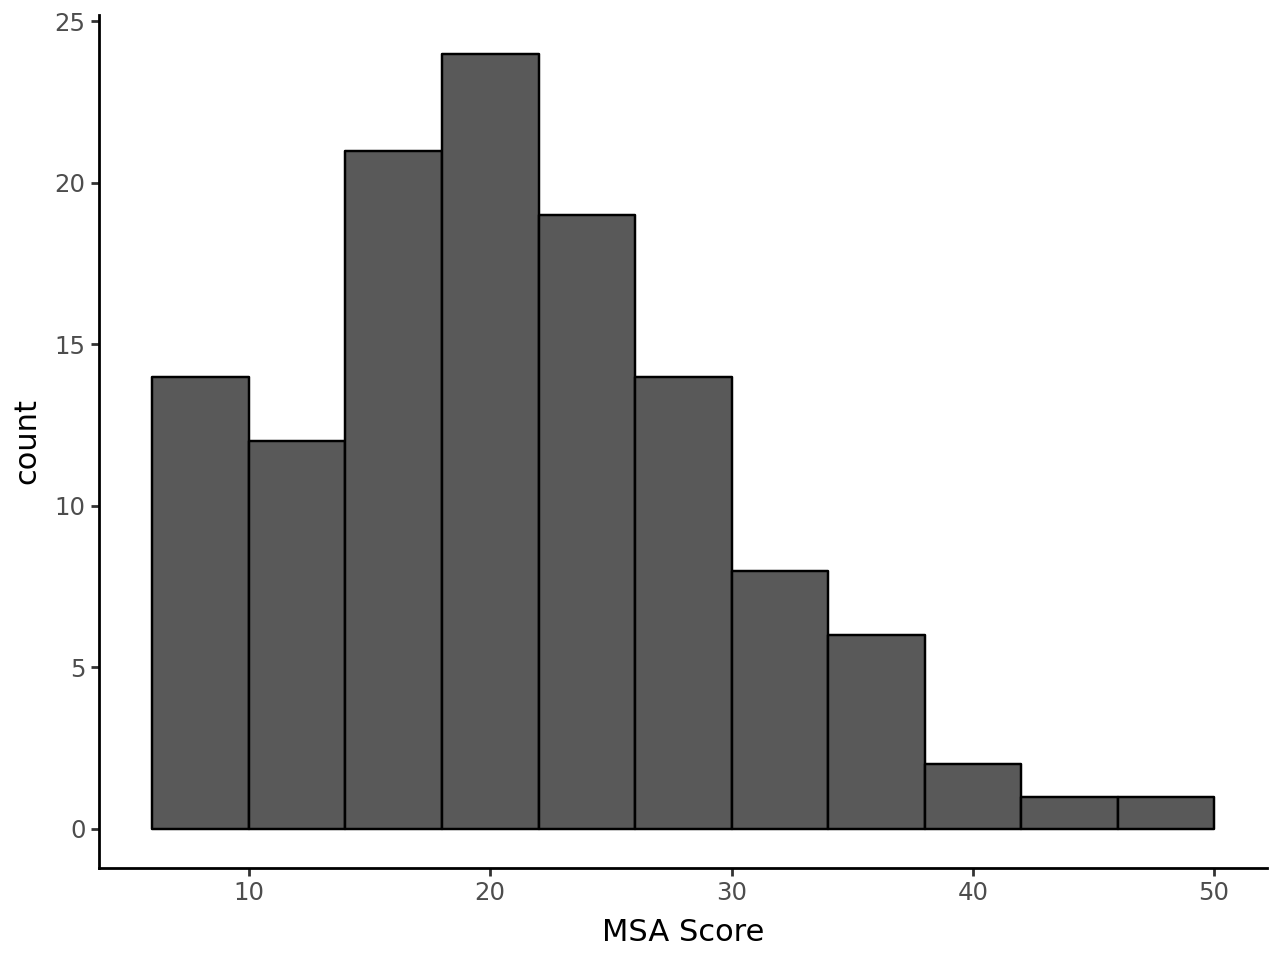

In [22]:
import plotnine as p9
import numpy as np

p9.ggplot(df) + p9.aes(x = "msa") + p9.geom_histogram(binwidth=4, color="black") + p9.theme_classic() + p9.labs(title = "", x = "MSA Score")

In [23]:
# too few datapoints with non-binary and prefer not to say, which lead to a less accurate model

df = df[~df['gender'].isin(['Non-binary', 'Prefer not to say'])]

In [24]:
# this code calculates and shows the model

# dispositional attitudes - the most predictive category overall
import statsmodels.api as sm
formula_string = "msa ~ idaq + social_tendency + perceived_reciprocity + relationship_substitution"

model_full = sm.formula.ols(formula = formula_string, data = df)
model_full_fitted = model_full.fit()

print(model_full_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:                    msa   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     17.60
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           3.10e-11
Time:                        00:43:28   Log-Likelihood:                -388.95
No. Observations:                 117   AIC:                             787.9
Df Residuals:                     112   BIC:                             801.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [25]:
# demographics have very little correlation, combined with their being many variables causes a massively overfitted model
formula_string = "msa ~ age + C(gender) + education_level + bg_arts + bg_business + bg_humanities + bg_stem + bg_social_sciences +	bg_liberal_arts"

model_full = sm.formula.ols(formula = formula_string, data = df)
model_full_fitted = model_full.fit()

print(model_full_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:                    msa   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.9762
Date:                Thu, 11 Jun 2026   Prob (F-statistic):              0.464
Time:                        00:43:28   Log-Likelihood:                -405.45
No. Observations:                 115   AIC:                             830.9
Df Residuals:                     105   BIC:                             858.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             16.9467      3

In [26]:
# use 
formula_string = "msa ~ use_frequency + time_since_adoption + session_duration + emotional_frequency + polite_frequency + pr_reciprocity + pr_response_quality + pr_discomfort + pr_habit + use_coding + use_creative_projects + use_general_conversation + use_learning_or_study + use_personal_or_emotional_discussion + use_writing_assistance + use_professional_tasks + use_information_search	+ use_idea_generation"

model_full = sm.formula.ols(formula = formula_string, data = df)
model_full_fitted = model_full.fit(cov_type='HC3')

print(model_full_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:                    msa   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     1.762
Date:                Thu, 11 Jun 2026   Prob (F-statistic):             0.0452
Time:                        00:43:28   Log-Likelihood:                -336.30
No. Observations:                  99   AIC:                             710.6
Df Residuals:                      80   BIC:                             759.9
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [27]:
# LLM model - model choice has little correlation
formula_string = "msa ~ llm_chatgpt	+ llm_claude + llm_copilot + llm_gemini + llm_grok"
model_full = sm.formula.ols(formula = formula_string, data = df)
model_full_fitted = model_full.fit(cov_type='HC3')

print(model_full_fitted.summary())


                            OLS Regression Results                            
Dep. Variable:                    msa   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     2.879
Date:                Thu, 11 Jun 2026   Prob (F-statistic):             0.0175
Time:                        00:43:28   Log-Likelihood:                -411.24
No. Observations:                 117   AIC:                             834.5
Df Residuals:                     111   BIC:                             851.1
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      17.2213      1.802      9.557      

In [28]:
# full model - every variable
formula_string = "msa ~ literacy + idaq + social_tendency + perceived_reciprocity + relationship_substitution + age + C(gender) + education_level + bg_arts + bg_business + bg_humanities + bg_stem + bg_social_sciences + bg_liberal_arts + use_frequency + time_since_adoption + session_duration + emotional_frequency + polite_frequency + pr_reciprocity + pr_response_quality + pr_discomfort + pr_habit + llm_chatgpt + llm_claude + llm_copilot + llm_gemini + llm_grok + use_coding + use_creative_projects + use_general_conversation + use_learning_or_study + use_personal_or_emotional_discussion + use_writing_assistance + use_professional_tasks + use_information_search + use_idea_generation"
model_full = sm.formula.ols(formula = formula_string, data = df)
model_full_fitted = model_full.fit()

print(model_full_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:                    msa   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     2.292
Date:                Thu, 11 Jun 2026   Prob (F-statistic):            0.00215
Time:                        00:43:28   Log-Likelihood:                -299.24
No. Observations:                  97   AIC:                             674.5
Df Residuals:                      59   BIC:                             772.3
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [29]:
# reduced model

formula_string = "msa ~ idaq + social_tendency + age + bg_arts + use_frequency + time_since_adoption + session_duration + emotional_frequency + polite_frequency + pr_reciprocity + pr_habit + llm_chatgpt+ llm_claude + llm_gemini + llm_grok + use_professional_tasks"
model_full = sm.formula.ols(formula = formula_string, data = df)
model_full_fitted = model_full.fit()

print(model_full_fitted.summary())

# removing any variables from this model reduces Adj. R-squared

                            OLS Regression Results                            
Dep. Variable:                    msa   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     6.700
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.04e-09
Time:                        00:43:28   Log-Likelihood:                -308.72
No. Observations:                  99   AIC:                             651.4
Df Residuals:                      82   BIC:                             695.6
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 10

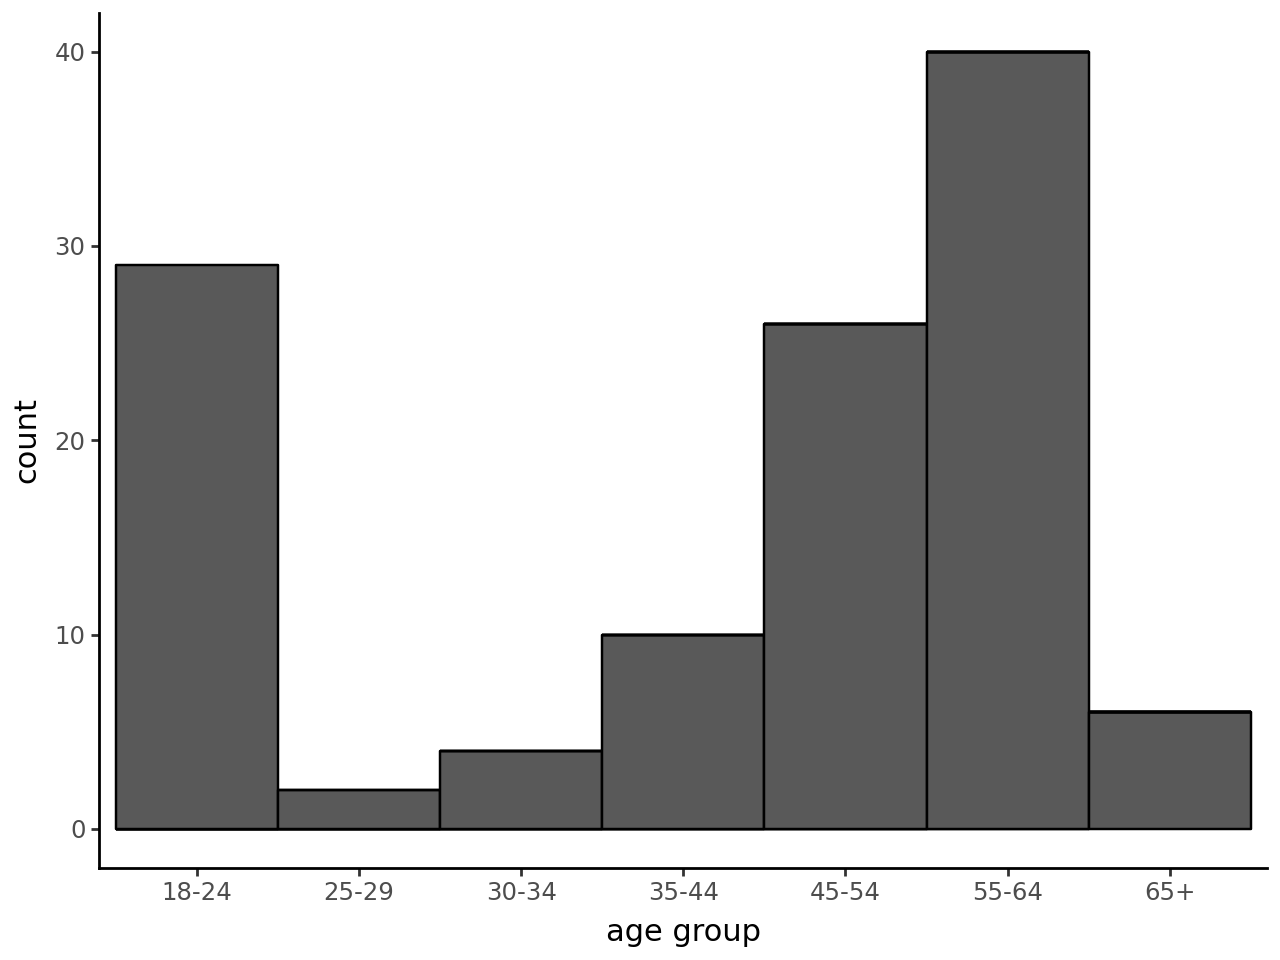

In [30]:
p9.ggplot(df) + p9.aes(x = "age_group") + p9.geom_histogram(binwidth=1, color="black") + p9.theme_classic() + p9.labs(title = "", x = "age group")

/opt/conda/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 36 rows containing missing values.


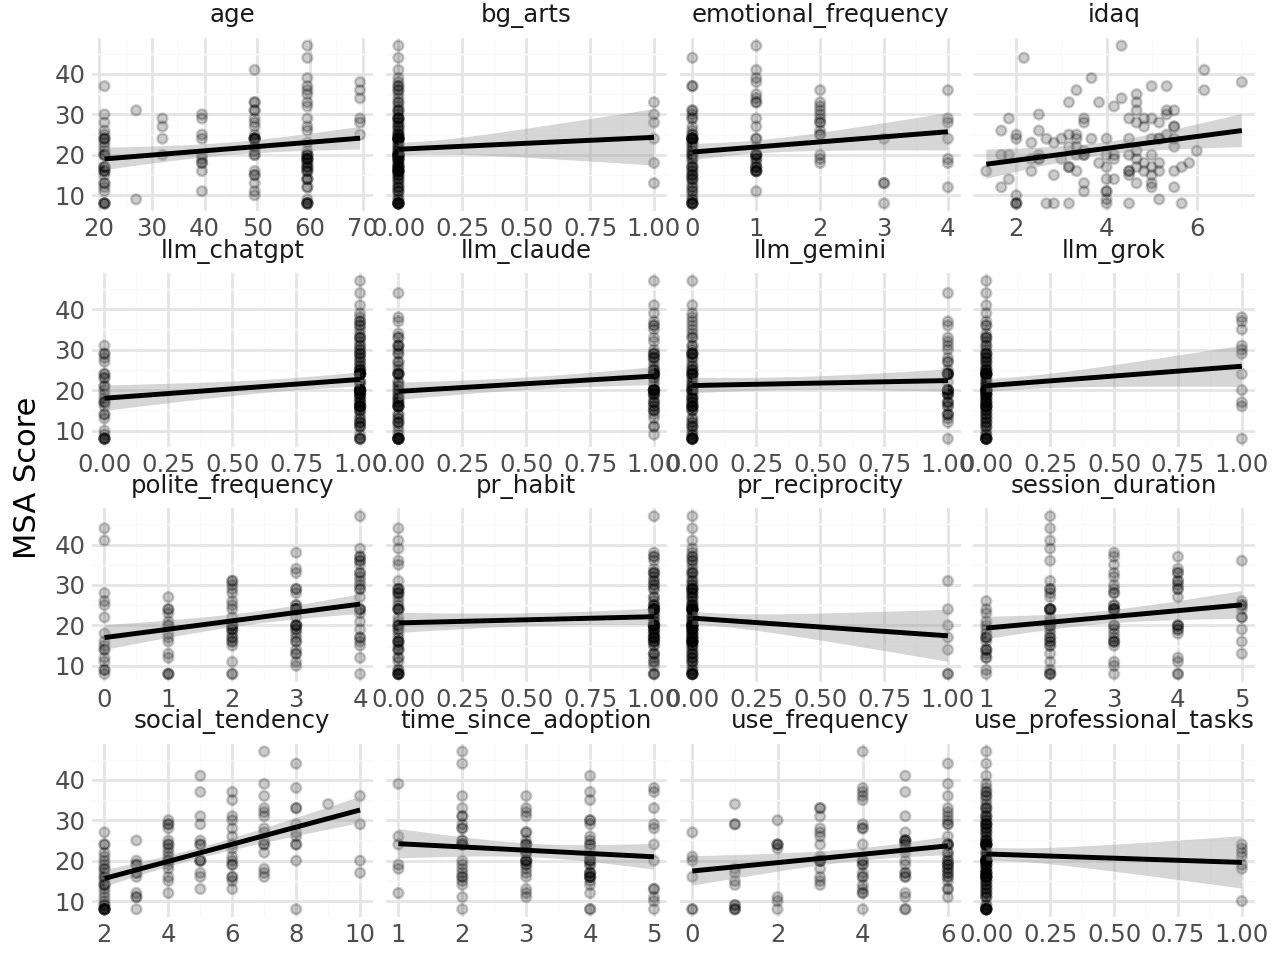

In [31]:
x_vars = ['idaq', 'social_tendency', 'age', 'bg_arts', 'use_frequency', 'time_since_adoption', 'session_duration', 
          'emotional_frequency', 'polite_frequency', 'pr_reciprocity', 'pr_habit', 'llm_chatgpt', 'llm_claude', 'llm_gemini', 'llm_grok', 'use_professional_tasks']

plot_df = df.melt(
    id_vars=['msa'],
    value_vars=x_vars,
    var_name='predictor',
    value_name='x'
)

(
    p9.ggplot(plot_df, p9.aes(x='x', y='msa'))
    + p9.geom_point(alpha=0.2)
    + p9.geom_smooth(method='lm')
    + p9.facet_wrap('~ predictor', scales='free_x')
     + p9.labs(x='', y='MSA Score')
    + p9.theme_minimal()
)

## Additional Charts

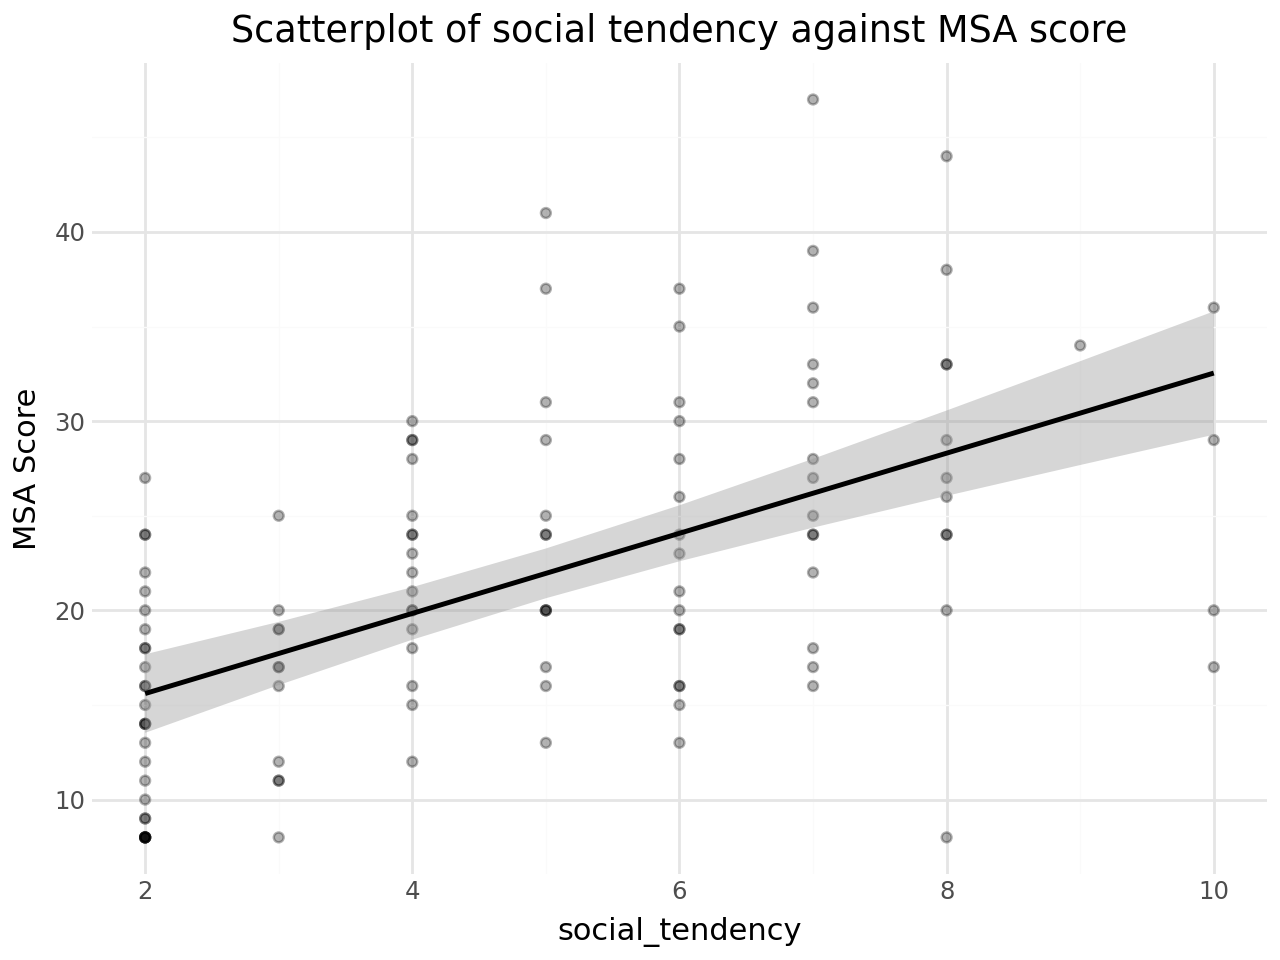

In [121]:
(
    p9.ggplot(df) + p9.aes(x = "social_tendency", y = "msa") + p9.geom_point(alpha = 0.3)
    +  p9.geom_smooth(method = "lm") + p9.theme_minimal()
    + p9.labs(title = "Scatterplot of social tendency against MSA score", x = "social_tendency", y = "MSA Score")
    )

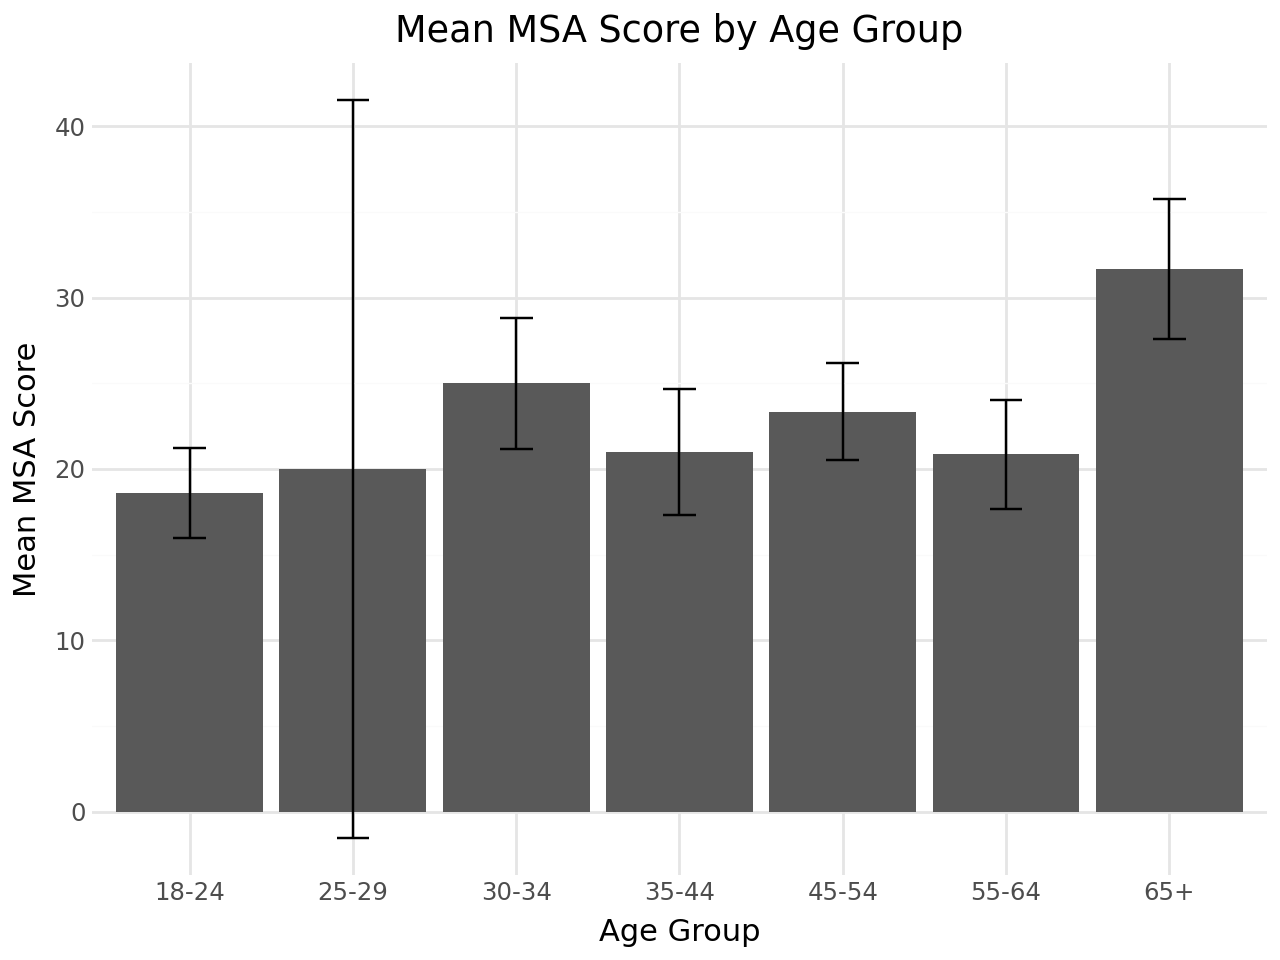

In [110]:
# confidence intervals need standard deviation to be calculated
summary = (
    df.groupby('age_group')['msa']
      .agg(['mean', 'std', 'count'])
      .reset_index()
)

summary['se'] = summary['std'] / np.sqrt(summary['count'])

# 95% CI using normal approximation
summary['lower'] = summary['mean'] - 1.96 * summary['se']
summary['upper'] = summary['mean'] + 1.96 * summary['se']

(
    p9.ggplot(summary, p9.aes(x='age_group', y='mean'))
    + p9.geom_col()
    + p9.geom_errorbar(
        p9.aes(ymin='lower', ymax='upper'),
        width=0.2
    )
    + p9.labs(
        x='Age Group',
        y='Mean Literacy Score',
        title='Mean MSA Score by Age Group'
    )
    + p9.theme_minimal()
)

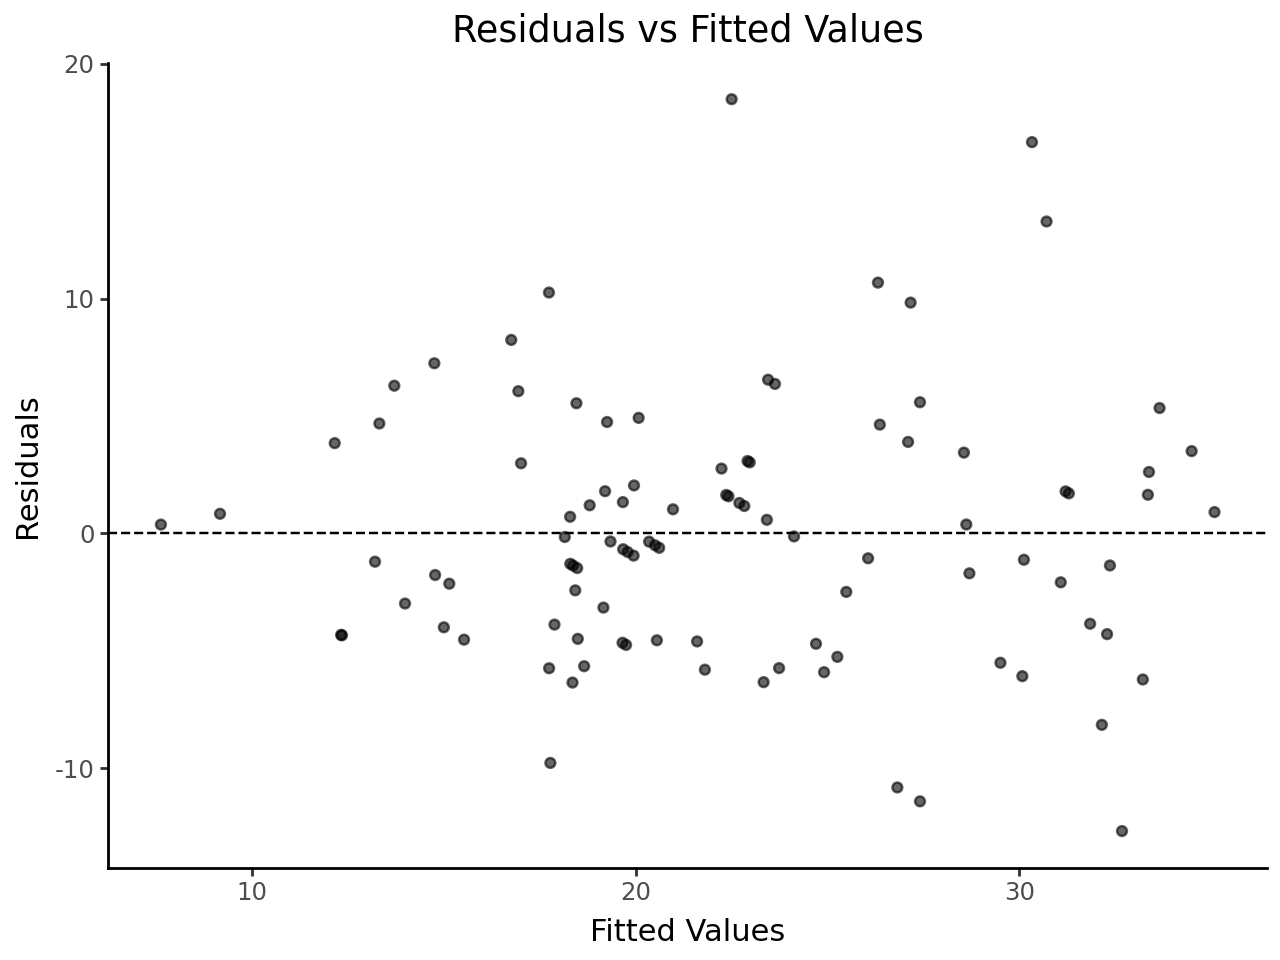

In [107]:
resid_df = pd.DataFrame({
    'fitted': model_full_fitted.fittedvalues,
    'residuals': model_full_fitted.resid
})

(
    p9.ggplot(resid_df, p9.aes(x='fitted', y='residuals'))
    + p9.geom_point(alpha=0.6)
    + p9.geom_hline(yintercept=0, linetype='dashed')
    + p9.labs(x='Fitted Values',y='Residuals',title='Residuals vs Fitted Values'
    )
    + p9.theme_classic()
)